# **1. Perkenalan Dataset**


**1. Sumber Dataset:**
Dataset yang digunakan dalam proyek ini diambil dari platform Kaggle dengan judul **[Customer Shopping Latest Trends Dataset](https://)** yang dipublikasikan oleh Mohit Bhadra. 

**2. Deskripsi Umum Dataset:**
Dataset ini berisi rekam jejak transaksi ritel simulasi yang mencakup informasi komprehensif mengenai perilaku belanja pelanggan. Data ini memiliki berbagai fitur (*features*) yang terbagi menjadi data demografis (seperti Usia, Jenis Kelamin, Lokasi), data transaksi (Total Pembelian, Kategori Barang), serta data perilaku (Frekuensi Belanja, Penggunaan Promo, dan Status Langganan). 

**3. Tujuan Proyek (Customer Segmentation):**
Tujuan utama dari proyek ini adalah mengimplementasikan algoritma *Machine Learning* (*Unsupervised Learning*) untuk melakukan **Segmentasi Pelanggan (Customer Segmentation)**. Dengan menganalisis pola pembelian dan karakteristik demografis, model akan mengelompokkan pelanggan ke dalam beberapa klaster/segmen unik (Pelanggan Loyal, Pemburu Diskon, atau Pelanggan Pasif). Hasil segmentasi ini dapat digunakan untuk merancang strategi pemasaran yang lebih personal dan tepat sasaran.


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # Untuk menyamakan skala angka
from sklearn.preprocessing import LabelEncoder   # Untuk mengubah teks kategori menjadi angka
from sklearn.cluster import KMeans               # Algoritma utama untuk segmentasi
from sklearn.metrics import silhouette_score     # Untuk mengevaluasi kualitas klaster
import warnings
warnings.filterwarnings('ignore')
print("Semua library berhasil diimpor")

Matplotlib is building the font cache; this may take a moment.


Semua library berhasil diimpor


# **3. Memuat Dataset**

In [13]:
file_path = "C:\\Users\\LENOVO\\Desktop\\kulyeahhhhhh\\Pijak\\MSML_Firda-Azzahra\\Eksperimen_SML_Firda-Azzahra\\Customer_shopping_dataset\\shopping_trends.csv"
df = pd.read_csv(file_path)
print("Dataset berhasil dimuat")
print("Tampilan 5 baris pertama dataset:")
df.head()

Dataset berhasil dimuat
Tampilan 5 baris pertama dataset:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [14]:
print("\nInformasi dataset:")
df.info()


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14 

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, **Exploratory Data Analysis (EDA)** dilakukan untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

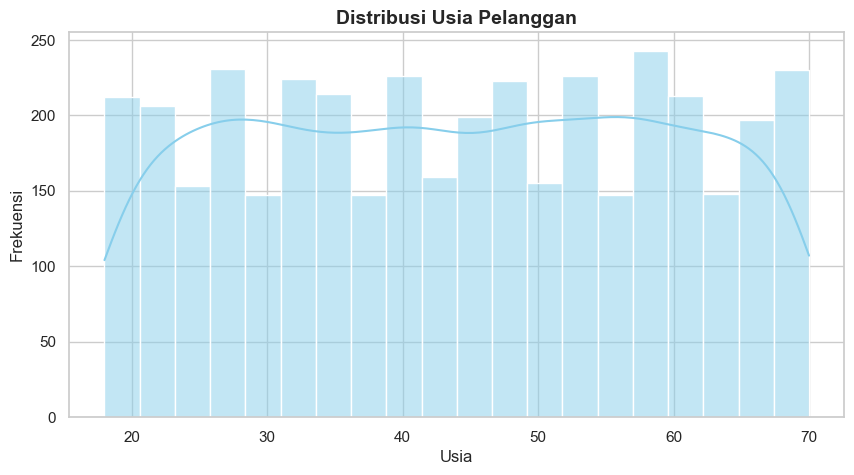

In [15]:
# Visualisasi data target
sns.set_theme(style="whitegrid")

# Visualisasi 1: Distribusi Usia Pelanggan
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Usia Pelanggan', fontsize=14, fontweight='bold')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.show()

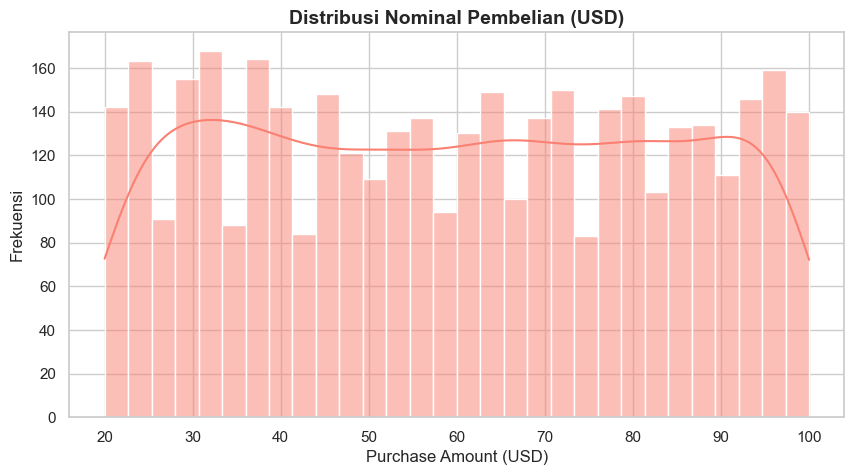

In [16]:
# Visualisasi 2: Distribusi Nominal Pembelian (Purchase Amount)
plt.figure(figsize=(10, 5))
sns.histplot(df['Purchase Amount (USD)'], bins=30, kde=True, color='salmon')
plt.title('Distribusi Nominal Pembelian (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frekuensi')
plt.show()

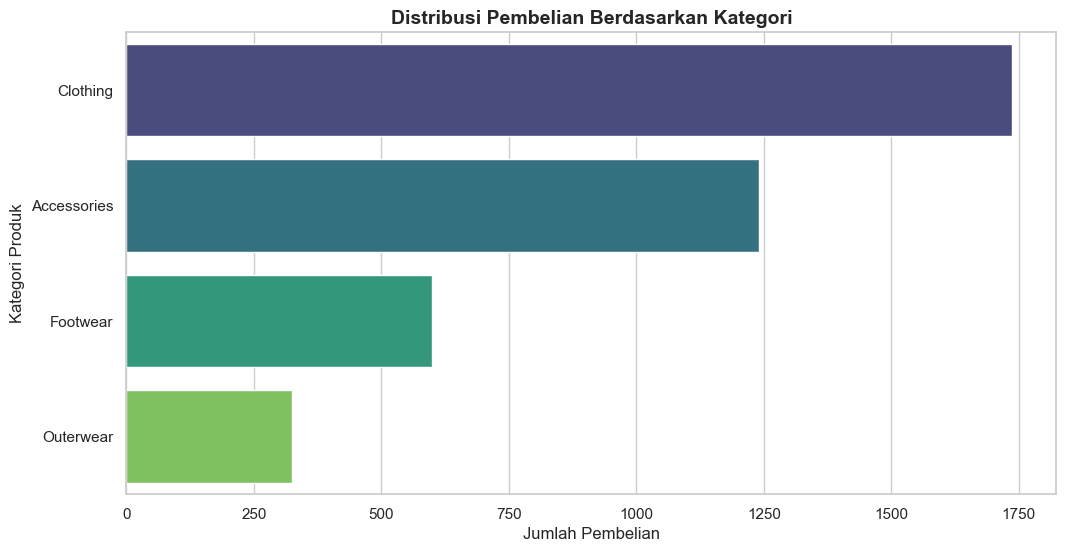

In [17]:
# Visualisasi 3: Kategori Produk yang Paling Diminati
plt.figure(figsize=(12, 6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribusi Pembelian Berdasarkan Kategori', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Kategori Produk')
plt.show()

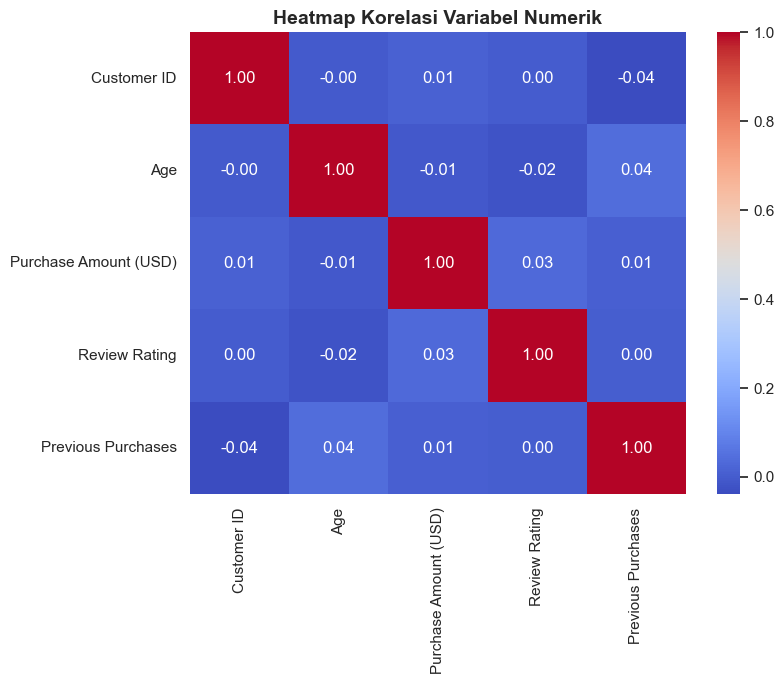

In [18]:
# Visualisasi 4: Korelasi antar Variabel Numerik
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=14, fontweight='bold')
plt.show()

### Kesimpulan Exploratory Data Analysis (EDA)

Berdasarkan tahapan eksplorasi dan visualisasi data yang telah dilakukan, kita dapat menarik kesimpulan/insight utama mengenai karakteristik data:

* **Distribusi Demografi & Transaksi Seragam:** Usia pelanggan (rentang 20-70 tahun) dan nominal transaksi (rentang 20-100 USD) tersebar secara merata. Hal ini menunjukkan bahwa bisnis ritel ini memiliki daya tarik universal dan tidak didominasi oleh kelompok usia atau daya beli tertentu.
* **Dominasi Kategori Produk Utama:** Terdapat ketimpangan preferensi yang sangat jelas pada jenis barang yang dibeli. Kategori **Clothing** (Pakaian) dan **Accessories** (aksesoris) mendominasi mayoritas transaksi, menjadikannya sebagai produk yang menjadi pendapatan utama toko.
* **Tidak Adanya Korelasi Linear:** Hasil dari *Heatmap* korelasi menunjukkan angka yang mendekati nol antar variabel numerik (contoh: usia pelanggan tidak memiliki pengaruh terhadap seberapa banyak mereka berbelanja).
* **Rencana Tindak Lanjut (Modeling):** Karena variabel secara individu tidak membentuk pola yang jelas, pemodelan tidak bisa hanya mengandalkan satu atau dua kolom mentah. Tahap selanjutnya wajib melibatkan algoritma *Clustering* multivariabel (seperti K-Means) yang didahului dengan proses prapemrosesan data (*Feature Engineering* dan *Encoding*) agar AI dapat menemukan pola segmen pelanggan yang tersembunyi.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. seperti:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)


In [19]:
print("\nPengecekan Missing Values secara Spesifik:")
print(df.isnull().sum())

print("\nPengecekan Data Duplikat:")
print("Jumlah duplikat:", df.duplicated().sum())

print("\nStatistik Deskriptif (Kolom Numerik):")
display(df.describe())


Pengecekan Missing Values secara Spesifik:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Pengecekan Data Duplikat:
Jumlah duplikat: 0

Statistik Deskriptif (Kolom Numerik):


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [20]:
# Membuat salinan dataframe agar data asli (df) tidak tertimpa
df_prep = df.copy()

# Hapus kolom identifier yang tidak memiliki nilai analitik
if 'Customer ID' in df_prep.columns:
    df_prep = df_prep.drop('Customer ID', axis=1)
df_prep.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [21]:
# Binning & Feature Encoding
# a. Binning Data Usia: Mengubah angka kontinu menjadi grup ordinal
bins = [0, 25, 45, 65, 100]
labels = ['Gen Z', 'Millennials', 'Gen X', 'Boomers']
df_prep['Age_Group'] = pd.cut(df_prep['Age'], bins=bins, labels=labels)

# b. Label Encoding: Untuk data biner (Yes/No) dan fitur ordinal (memiliki tingkatan)
le = LabelEncoder()
binary_cols = ['Gender', 'Subscription Status', 'Discount Applied', 'Promo Code Used']
for col in binary_cols:
    df_prep[col] = le.fit_transform(df_prep[col]) # Contoh: Yes->1, No->0

# Encode hasil binning (Age_Group) menggunakan LabelEncoder
df_prep['Age_Group_Encoded'] = le.fit_transform(df_prep['Age_Group'])

# Hapus kolom 'Age' asli dan 'Age_Group' (karena sudah di-encode ke angka)
df_prep = df_prep.drop(['Age', 'Age_Group'], axis=1)

# c. One-Hot Encoding: Untuk data nominal (kategori tanpa tingkatan logis)
# drop_first=True digunakan untuk menghindari jebakan multikolinearitas (Dummy Variable Trap)
nominal_cols = ['Category', 'Season', 'Frequency of Purchases']
df_prep = pd.get_dummies(df_prep, columns=nominal_cols, drop_first=True)

# Membuang kolom teks yang terlalu spesifik (kardinalitas tinggi) untuk pemodelan awal
cols_to_drop = ['Location', 'Item Purchased', 'Size', 'Color', 'Payment Method', 'Shipping Type']
df_prep = df_prep.drop(columns=[col for col in cols_to_drop if col in df_prep.columns])

df_prep.head()

,Gender,Purchase Amount (USD),Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Age_Group_Encoded,Category_Clothing,...,Category_Outerwear,Season_Spring,Season_Summer,Season_Winter,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,1,53,3.1,1,1,1,14,Venmo,1,True,...,False,False,False,True,False,False,True,False,False,False
1,1,64,3.1,1,1,1,2,Cash,2,True,...,False,False,False,True,False,False,True,False,False,False
2,1,73,3.1,1,1,1,23,Credit Card,1,True,...,False,True,False,False,False,False,False,False,False,True
3,1,90,3.5,1,1,1,49,PayPal,2,False,...,False,True,False,False,False,False,False,False,False,True
4,1,49,2.7,1,1,1,31,PayPal,3,True,...,False,True,False,False,False,False,False,False,False,False


In [22]:
# check fitur yang ada
df_prep.columns.tolist()

['Gender',
 'Purchase Amount (USD)',
 'Review Rating',
 'Subscription Status',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Preferred Payment Method',
 'Age_Group_Encoded',
 'Category_Clothing',
 'Category_Footwear',
 'Category_Outerwear',
 'Season_Spring',
 'Season_Summer',
 'Season_Winter',
 'Frequency of Purchases_Bi-Weekly',
 'Frequency of Purchases_Every 3 Months',
 'Frequency of Purchases_Fortnightly',
 'Frequency of Purchases_Monthly',
 'Frequency of Purchases_Quarterly',
 'Frequency of Purchases_Weekly']

In [23]:
# Handling outlier data
numeric_cols = ['Purchase Amount (USD)', 'Previous Purchases']

for col in numeric_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Menentukan batas wajar
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping (Winsorizing): Mengubah nilai ekstrem menjadi sama dengan batas maksimum/minimumnya
    # Ini lebih baik daripada menghapus baris (drop) karena kita tidak kehilangan data transaksi
    df_prep[col] = np.where(df_prep[col] > upper_bound, upper_bound, df_prep[col])
    df_prep[col] = np.where(df_prep[col] < lower_bound, lower_bound, df_prep[col])

df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [24]:
# feature scaling 
# Mengubah skala data agar memiliki rata-rata 0 dan standar deviasi 1.
# Hal ini wajib agar fitur bernilai ribuan tidak mendominasi fitur bernilai satuan (seperti rating).
scaler = StandardScaler()

cols_to_scale = ['Purchase Amount (USD)', 'Previous Purchases', 'Review Rating']
df_prep[cols_to_scale] = scaler.fit_transform(df_prep[cols_to_scale])

# Pengecekan hasil akhir
print("Tipe data setelah preprocessing:")
print(df_prep.dtypes.value_counts())
print("\nBentuk data:", df_prep.shape)
display(df_prep.head())

Tipe data setelah preprocessing:
bool       12
int64       5
float64     3
str         1
Name: count, dtype: int64

Bentuk data: (3900, 21)


,Gender,Purchase Amount (USD),Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Age_Group_Encoded,Category_Clothing,...,Category_Outerwear,Season_Spring,Season_Summer,Season_Winter,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,1,-0.285629,-0.907584,1,1,1,-0.785831,Venmo,1,True,...,False,False,False,True,False,False,True,False,False,False
1,1,0.178852,-0.907584,1,1,1,-1.616552,Cash,2,True,...,False,False,False,True,False,False,True,False,False,False
2,1,0.558882,-0.907584,1,1,1,-0.162789,Credit Card,1,True,...,False,True,False,False,False,False,False,False,False,True
3,1,1.276716,-0.349027,1,1,1,1.637107,PayPal,2,False,...,False,True,False,False,False,False,False,False,False,True
4,1,-0.454531,-1.466141,1,1,1,0.391025,PayPal,3,True,...,False,True,False,False,False,False,False,False,False,False
